In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy import signal
import h5py
import os
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
import matplotlib.patheffects as patheffects
import matplotlib.lines as mlines

## Update For Google Colab
# sys.path.append('/content/drive/MyDrive/')

## Update For Local
sys.path.append('/path/to/my/all_projects') ## e.g. sys.path.append('/data/sswar_files/0_PUBLISHED_CODES')

from SPEC2VEC.utils.simple_synth_data_models import *
from SPEC2VEC.utils.spectograms_lib import * 
from SPEC2VEC.utils.noise_lib import * 
from SPEC2VEC.utils.gisqa_compute_updated import *
from SPEC2VEC.utils.gisqa_plotting import *
from SPEC2VEC.utils.gisqa_helper import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/sswar/.local/lib/python3.10/site-packages/porespy/filters/_lt_methods.py:21: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  strel = {2: {'min': disk(1), 'max': square(3)}, 3: {'min': ball(1), 'max': cube(3)}}
/home/sswar/.local/lib/python3.10/site-packages/porespy/filters/_lt_methods.py:21: FutureWarning: `cube` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  strel = {2: {'min': disk(1), 'max': square(3)}, 3: {'min': ball(1), 'max': cube(3)}}
/home/sswar/.local/lib/python3.10/site-packages/porespy/metrics/_funcs.py:65: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  strel = {2: {"min": disk(1), "max": square(3)}, 3: {"min": ball(1), "max": cube(3)}}
/home/sswar/.local/lib/python3.10/site-packages/pores

#### Data Prep

In [3]:
## Signal Prams
fs = 250
T = 10
L = int(fs*T)

## Spec Params
window = "hamming"
vmin = 2
vmax = 98
f_min = 0
f_max = 125
t = np.linspace(0, T, L, endpoint=False)

# 20 Hz sine burst around 2 sec (Gaussian window centered at 2s)
burst1 = np.sin(2 * np.pi * 20 * t) * np.exp(-((t - 2) ** 2) / (2 * 0.3 ** 2))

# 35 Hz sine burst around 6 sec (Gaussian window centered at 6s)
burst2 = np.sin(2 * np.pi * 35 * t) * np.exp(-((t - 6) ** 2) / (2 * 0.3 ** 2))

# Add a 60 Hz sine burst around 8 sec (Gaussian window centered at 8s)
burst3 = np.sin(2 * np.pi * 60 * t) * np.exp(-((t - 8) ** 2) / (2 * 0.25 ** 2))

# Add a frequency-modulated signal (FM) centered at 4 sec
fm_mod = np.sin(2 * np.pi * (15 + 10 * np.sin(2 * np.pi * 0.5 * t)) * t) * np.exp(-((t - 4) ** 2) / (2 * 0.5 ** 2))

# Add a random amplitude-modulated noise burst around 5 sec
amp_mod = np.random.uniform(0.5, 1.5, size=L) * np.sin(2 * np.pi * 25 * t)
amp_mod *= np.exp(-((t - 5) ** 2) / (2 * 0.2 ** 2))

# Chirp signal from 10 Hz to 5 Hz over 10 seconds
chirp_sig = signal.chirp(t, f0=10, f1=5, t1=T, method='linear')

# Add all new components to the signal
final_signal = burst1 + burst2 + burst3 + 2 * fm_mod + amp_mod + chirp_sig 

## Noise
if os.path.exists('other_data/SimpleSynth/simplesynth2_whitenoise.npy'):
    print('Noise Data Exists. Loading form File')
    white_noise = np.load('other_data/SimpleSynth/simplesynth2_whitenoise.npy', allow_pickle=True)
else:
    gen = ColoredNoiseGenerator(L)
    white_noise = gen.white()
    np.save('other_data/SimpleSynth/simplesynth2_whitenoise.npy', white_noise)

## Construct the Signal
final_signal = MinMaxScaler(feature_range=(-1,1)).fit_transform(final_signal.reshape(-1,1)).flatten()
white_noise = MinMaxScaler(feature_range=(-1,1)).fit_transform(white_noise.reshape(-1,1)).flatten()
final_signal = final_signal + (0.3)*white_noise

all_imgs_orig, all_names, all_ts, all_fs = HelperFunc.compute_series_of_tfrs(final_signal, 
                                                                                fs=fs, T=T, 
                                                                                vmin=vmin, vmax=vmax, 
                                                                                f_min=f_min, f_max=f_max,
                                                                                interp_shape=(128,148))
                                                                             
#### Reduce Noise
# all_imgs = []
# for img in all_imgs_orig:
#     tmpimg = img.copy()
#     tmpimg[tmpimg<np.percentile(tmpimg,50)]=0
#     all_imgs.append(tmpimg)

Noise Data Exists. Loading form File
Interpolating all TFRs to shape: (128, 148)


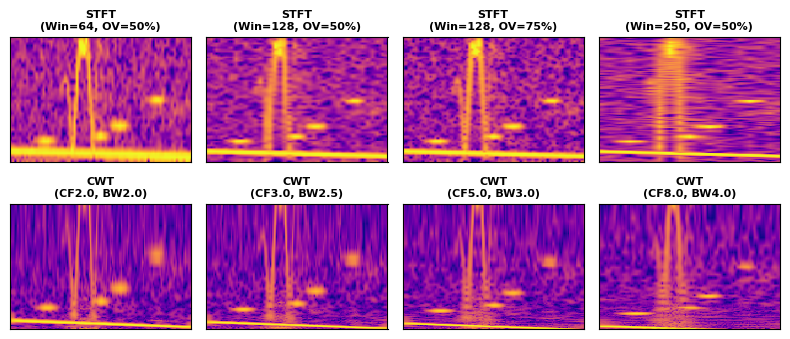

In [5]:
all_names = ['STFT\n(Win=64, OV=50%)','STFT\n(Win=128, OV=50%)','STFT\n(Win=128, OV=75%)','STFT\n(Win=250, OV=50%)',
             'CWT\n(CF2.0, BW2.0)','CWT\n(CF3.0, BW2.5)','CWT\n(CF5.0, BW3.0)','CWT\n(CF8.0, BW4.0)']

plt.figure(figsize=(8,3.5))
for i in range(len(all_imgs_orig)):
    plt.subplot(2,4,i+1)
    plt.imshow(all_imgs_orig[i], cmap='plasma', aspect='auto', origin='lower', interpolation='nearest')
    #plt.imshow(all_imgs[i], cmap='plasma', aspect='auto', origin='lower', interpolation='nearest')
    plt.title(all_names[i], fontsize=8, fontweight='bold')
    plt.xticks([]); plt.yticks([])
plt.tight_layout()
plt.show()

#### Compute Spec2Vec Metrics

In [22]:
entp_columns = [
                    'permutation_entropy_antropy', 
                    'spectral_entropy_antropy',
                    'svd_entropy_antropy', 
                    'petrosian_fd_antropy', 
                    'detrended_fluctuation_antropy', 
                    'hjorth_mobility_antropy',
                    'hjorth_complexity_antropy', 
                    'higuchi_fd_antropy',
                    'normalized_permutation_entropy_ordpy',
                    'statistical_complexity_entropy_ordpy', 
                    'fisher_shannon_ordpy',
                    'global_node_entropy_ordpy', 
                    'renyi_complexity_entropy_short_ordpy',
                    'renyi_stat_complexity_short_ordpy',
                    'renyi_complexity_entropy_long_ordpy',
                    'renyi_stat_complexity_long_ordpy',
                    'tsallis_complexity_entropy_long_ordpy',
                    'tsallis_stat_complexity_long_ordpy',
                    'weighted_permutation_entropy_ordpy', 
                    'missing_links_ordpy',
                    'Absolute energy', 
                    'Average power',
                    'Kurtosis', 
                    'Lempel-Ziv complexity', 
                    'Mean', 
                    'Median',
                    'Skewness', 
                    'Standard deviation',
                    '75th_percentile',
                    '25th_percentile',
                    'label'
                ]


In [ ]:
## Refernece File params
color_noise_bnk_metrics = ['other_data/MixedSettings/mixed_settings_img_bank_metrics_manuscript.csv']
ref_noise_metrics_df  = pd.read_csv(color_noise_bnk_metrics[0])

all_names = ['TFR1','TFR2','TFR3','TFR4','TFR5','TFR6','TFR7','TFR8']
all_keys = ['white_stft_w64_olap0.5','white_stft_w128_olap0.5', 'white_stft_w128_olap0.75','white_stft_w250_olap0.5',
            'white_cwt_wcmor2.0-2.0','white_cwt_wcmor3.0-2.5', 'white_cwt_wcmor5.0-3.0', 'white_cwt_wcmor8.0-4.0']

## Compute the Metrics Dataset
giq = GISQAPipeline()
spec_pointwise_metrics_df = giq.compute_pointwise_metrics_from_spec(all_names, all_imgs_orig,
                                                                    is_hilbertize = 1,
                                                                    is_normalize_stat = 0,
                                                                    is_normalize_entropy = 0,
                                                                    is_best_features = 0,
                                                                    ordpydx = 6, antropydx = 6,
                                                                    metrics_list=entp_columns, hilbert_locs=None)
                                                                    

1 number of row processed


In [ ]:
save_folder = 'other_data/all_figures'
save_path = save_folder
binary_keys = ['erdos_renyi_graph_0.4','erdos_renyi_graph_0.8','perlin_noise_0.4','perlin_noise_0.8']
noisebnk_path = 'other_data/MixedSettings/mixed_settings_img_bank_manuscript.hdf5'
noisebnk_keys = ref_noise_metrics_df.label.unique().tolist()

gipl = GISQAPipeline()
glzm_pairwise_metrics_df = pd.DataFrame([])
updated_spec_details_dict = {}
for t_plot, f_plot, spec_img, filename, key in zip(all_ts,all_fs,all_imgs_orig,all_names,all_keys):
    pairwise_metrics_temp, updated_spec_details = gipl.execute_pairwise_pipleine(t_plot=t_plot,
                                                                                 f_plot=f_plot,
                                                                                 spec_img=spec_img,
                                                                                 noisebnk_path=noisebnk_path,
                                                                                 noise_cutoff=98,
                                                                                 noisebnk_keys=noisebnk_keys,
                                                                                 binary_keys=binary_keys,
                                                                                 filename=filename,
                                                                                 gmm_mean_threshold=0.025,
                                                                                 optimization_params={'type':'exponential',
                                                                                                      'start':1,'end':1,'slope':1},
                                                                                 save_path=None,save_all_plots=False,
                                                                                 best_neighbour_key=key,
                                                                                 min_zone_size_thrshld=10)

    glzm_pairwise_metrics_df = pd.concat([glzm_pairwise_metrics_df,pairwise_metrics_temp], axis=0)
    updated_spec_details_dict[filename] = updated_spec_details

all_imgs_pdfsi = [updated_spec_details_dict[key]['spec_image_noise_cleaned'] for key in updated_spec_details_dict.keys()]
all_names_pdfsi = list(updated_spec_details_dict.keys())

In [25]:
entp_columns = ['permutation_entropy_antropy', 
                'spectral_entropy_antropy',
                'svd_entropy_antropy', 
                'petrosian_fd_antropy', 
                'detrended_fluctuation_antropy', 
                'hjorth_mobility_antropy',
                'hjorth_complexity_antropy', 
                'higuchi_fd_antropy',
                'normalized_permutation_entropy_ordpy',
                'statistical_complexity_entropy_ordpy', 
                'fisher_shannon_ordpy',
                'global_node_entropy_ordpy', 
                'renyi_complexity_entropy_long_ordpy',
                'renyi_stat_complexity_long_ordpy',
                'tsallis_complexity_entropy_long_ordpy',
                'tsallis_stat_complexity_long_ordpy',
                'weighted_permutation_entropy_ordpy', 
                '0_Lempel-Ziv complexity',
                'missing_links_ordpy',
                'label']

all_keys = ['white_stft_w64_olap0.5', 'white_stft_w128_olap0.5', 'white_stft_w128_olap0.75', 'white_stft_w250_olap0.5',
            'white_cwt_wcmor2.0-2.0', 'white_cwt_wcmor3.0-2.5', 'white_cwt_wcmor5.0-3.0', 'white_cwt_wcmor8.0-4.0']

ref_noise_metrics_entp_df = ref_noise_metrics_df[ref_noise_metrics_df['label'].str.startswith('white')].reset_index(drop=True)
ref_noise_metrics_entp_df = ref_noise_metrics_entp_df[entp_columns]
spec_entp_df = spec_pointwise_metrics_df[entp_columns].copy()

entp_l2 = HelperFunc.calculate_best_spectrogram_by_rmse(ref_noise_metrics_entp_df, 
                                                        spec_entp_df,
                                                        target_cols = entp_columns[:-1], 
                                                        label_col = 'label', 
                                                        method = 'median', 
                                                        spec_technique = all_keys, 
                                                        distance_type = 'cosine_distance',
                                                        pair_normalize = True,
                                                        normalize_method = 'MinMax',
                                                        normalize_with_ref = False,
                                                        remove_outliers = True)


Computing for ['white_stft_w64_olap0.5', 'white_stft_w128_olap0.5', 'white_stft_w128_olap0.75', 'white_stft_w250_olap0.5', 'white_cwt_wcmor2.0-2.0', 'white_cwt_wcmor3.0-2.5', 'white_cwt_wcmor5.0-3.0', 'white_cwt_wcmor8.0-4.0'] spectrograms and ['TFR1' 'TFR2' 'TFR3' 'TFR4' 'TFR5' 'TFR6' 'TFR7' 'TFR8'] labels


/tmp/ipykernel_2327085/294578573.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(entp_l2.keys(), rotation=45, fontweight='bold', ha='right')


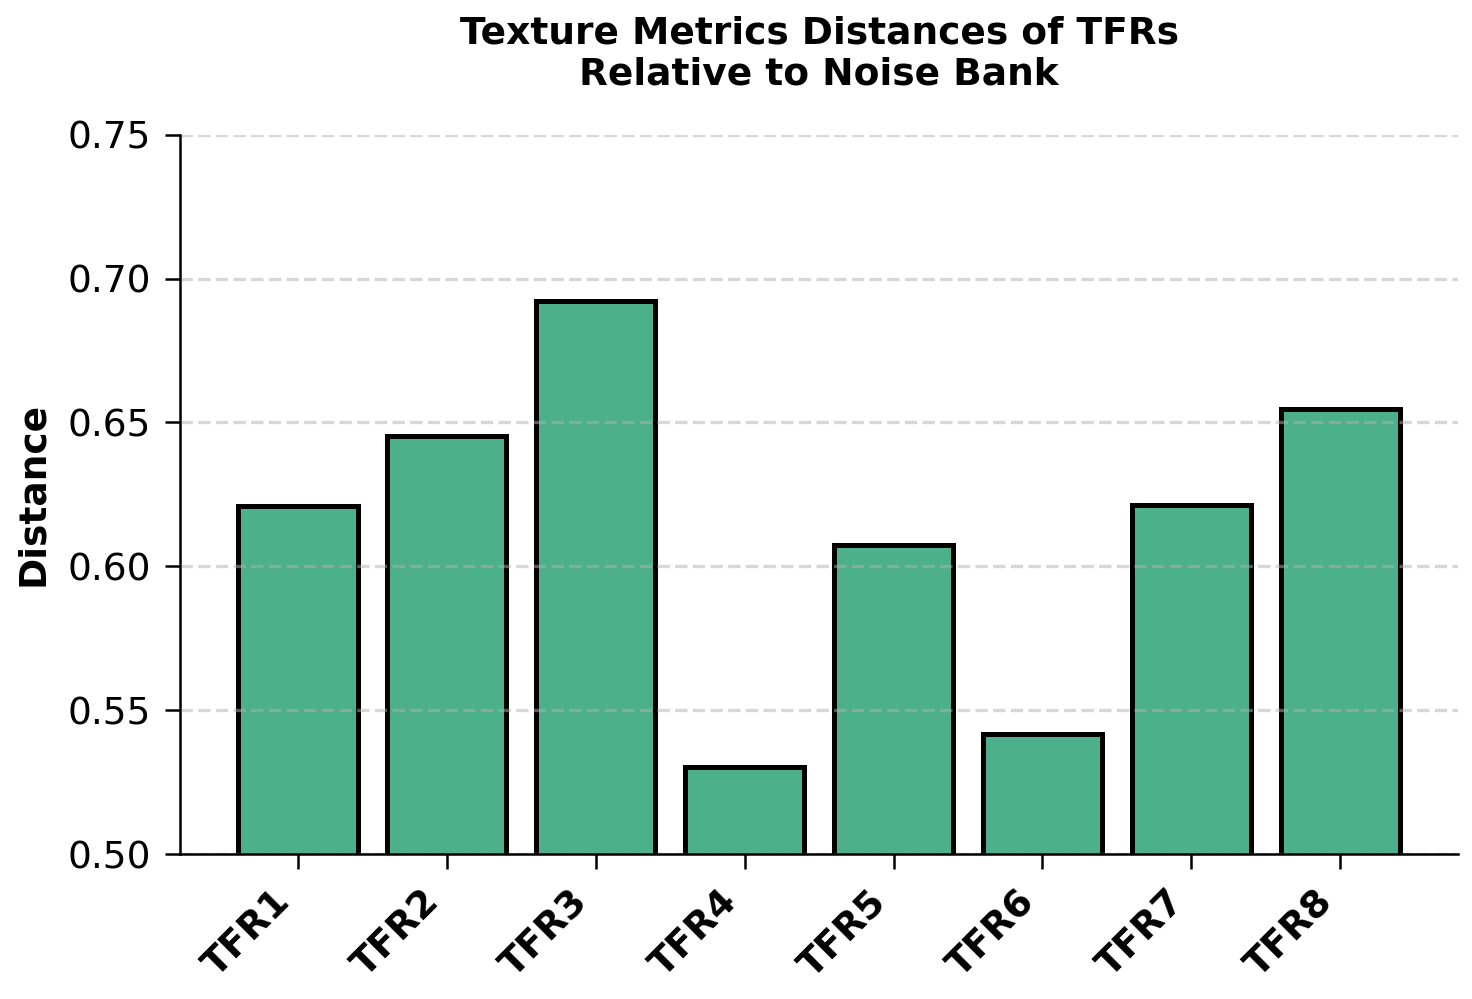

In [26]:
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(entp_l2.keys(), entp_l2.values(), 
              color="#4CB08A", edgecolor='black', linewidth=1.2)

ax.set_ylabel('Distance', fontsize=9, fontweight='bold')
ax.set_title('Texture Metrics Distances of TFRs\nRelative to Noise Bank', fontsize=9, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', labelsize=9)
ax.set_xticklabels(entp_l2.keys(), rotation=45, fontweight='bold', ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.5)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.ylim(0.5, 0.75)
plt.show()

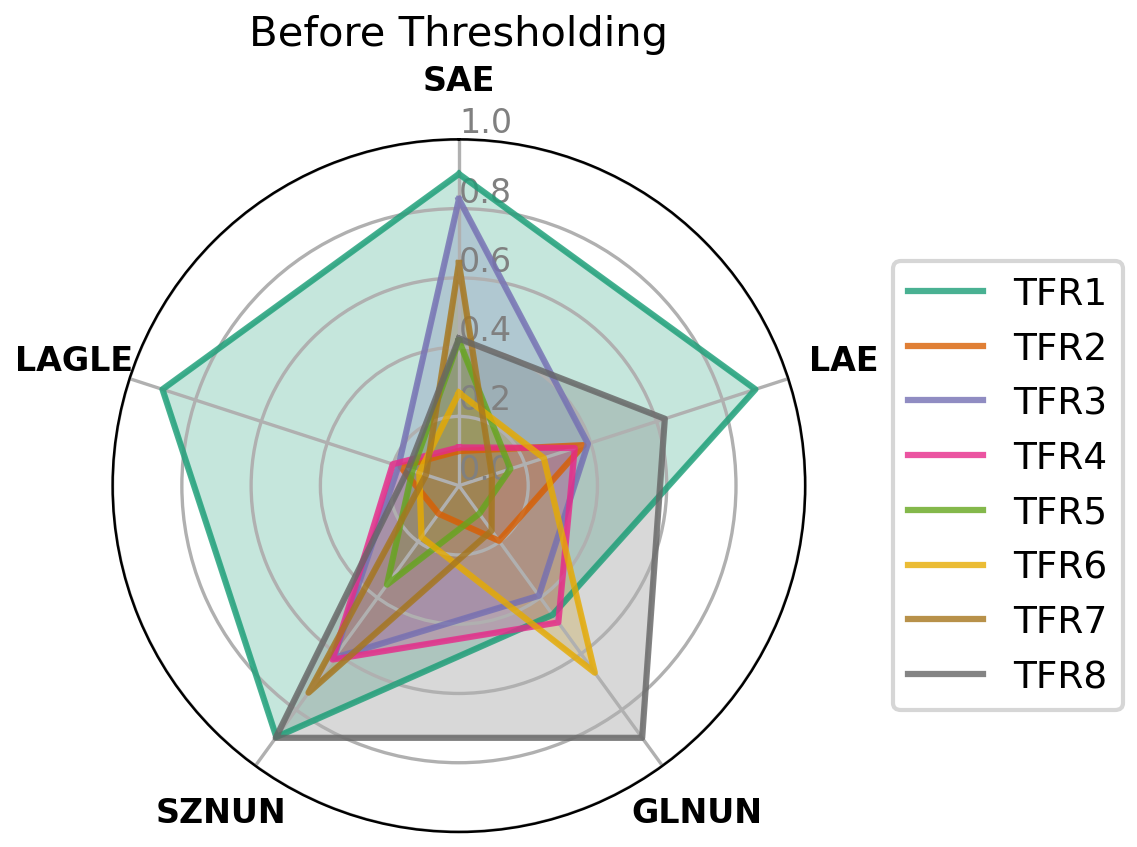

In [27]:
filtered_cols = [col for col in glzm_pairwise_metrics_df.columns if col.endswith('_stg1')]
glzm_pairwise_metrics_df_stg1 = glzm_pairwise_metrics_df[filtered_cols].copy()
glzm_pairwise_metrics_df_stg1.loc[:,'label'] = glzm_pairwise_metrics_df.loc[:,'label']

glzm_pairwise_metrics_df_stg1_scaled = MinMaxScaler(feature_range=(0.1,0.9)).fit_transform(glzm_pairwise_metrics_df_stg1.iloc[:,:-1])
glzm_pairwise_metrics_df_stg1_scaled = pd.DataFrame(glzm_pairwise_metrics_df_stg1_scaled, columns = glzm_pairwise_metrics_df_stg1.columns[:-1], 
                                                        index=glzm_pairwise_metrics_df_stg1['label'].tolist())                                                    
                                                        
fig, ax1 = plt.subplots(1,1, figsize=(4, 4), subplot_kw=dict(polar=True))
b4_area = gisqa_plots.plot_multi_row_radar_chart(
    df = glzm_pairwise_metrics_df_stg1_scaled.iloc[:,:-1], column_lables = ['SAE','LAE','GLNUN','SZNUN','LAGLE'], title='Before Thresholding',
    ax=ax1, cmap='Dark2')
plt.tight_layout(); 
plt.show()

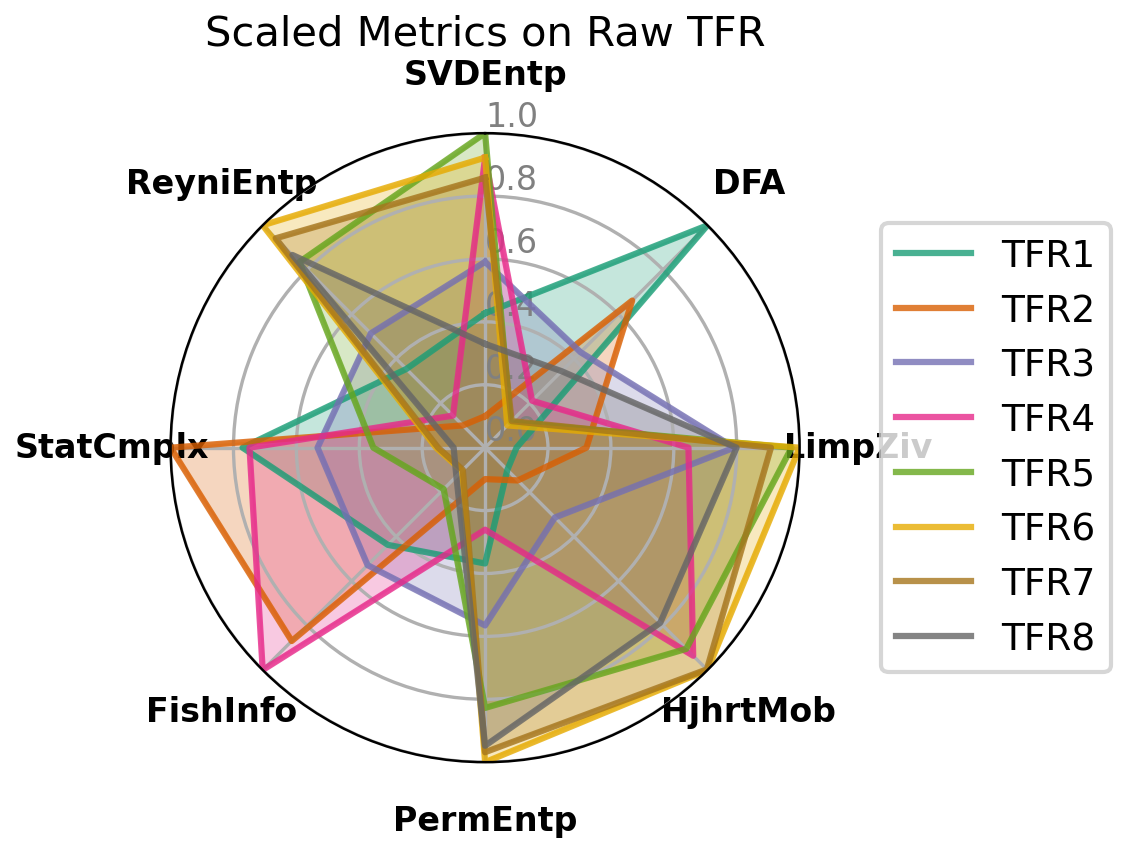

In [28]:
final_entp_list = ['svd_entropy_antropy','detrended_fluctuation_antropy','0_Lempel-Ziv complexity',
                   'hjorth_mobility_antropy','normalized_permutation_entropy_ordpy','fisher_shannon_ordpy',
                   'statistical_complexity_entropy_ordpy','renyi_complexity_entropy_long_ordpy']

all_keys = {'TFR1':'white_stft_w64_olap0.5', 'TFR2':'white_stft_w128_olap0.5',
            'TFR3':'white_stft_w128_olap0.75', 'TFR4':'white_stft_w250_olap0.5',
            'TFR5':'white_cwt_wcmor2.0-2.0', 'TFR6':'white_cwt_wcmor3.0-2.5', 
            'TFR7':'white_cwt_wcmor5.0-3.0', 'TFR8':'white_cwt_wcmor8.0-4.0'}

column_lables = ['SVDEntp','DFA','LimpZiv','HjhrtMob','PermEntp','FishInfo','StatCmplx','ReyniEntp']

upd_spec_entp_df = spec_pointwise_metrics_df[final_entp_list].copy()
upd_spec_entp_df_scaled = MinMaxScaler(feature_range=(0.1,1)).fit_transform(upd_spec_entp_df)
upd_spec_entp_df_scaled = pd.DataFrame(upd_spec_entp_df_scaled, columns = final_entp_list, 
                                       index=spec_pointwise_metrics_df['label'].tolist())

fig, ax1 = plt.subplots(1,1, figsize=(4, 4), subplot_kw=dict(polar=True))
areab4 = gisqa_plots.plot_multi_row_radar_chart(
    df = upd_spec_entp_df_scaled, column_lables = column_lables, 
    title='Scaled Metrics on Raw TFR', cmap='Dark2', ax=ax1
)
plt.tight_layout();
plt.show()

#### FIGURE MAIN: Consolidated Summary Figure

/tmp/ipykernel_2327085/2279025871.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Dark2')


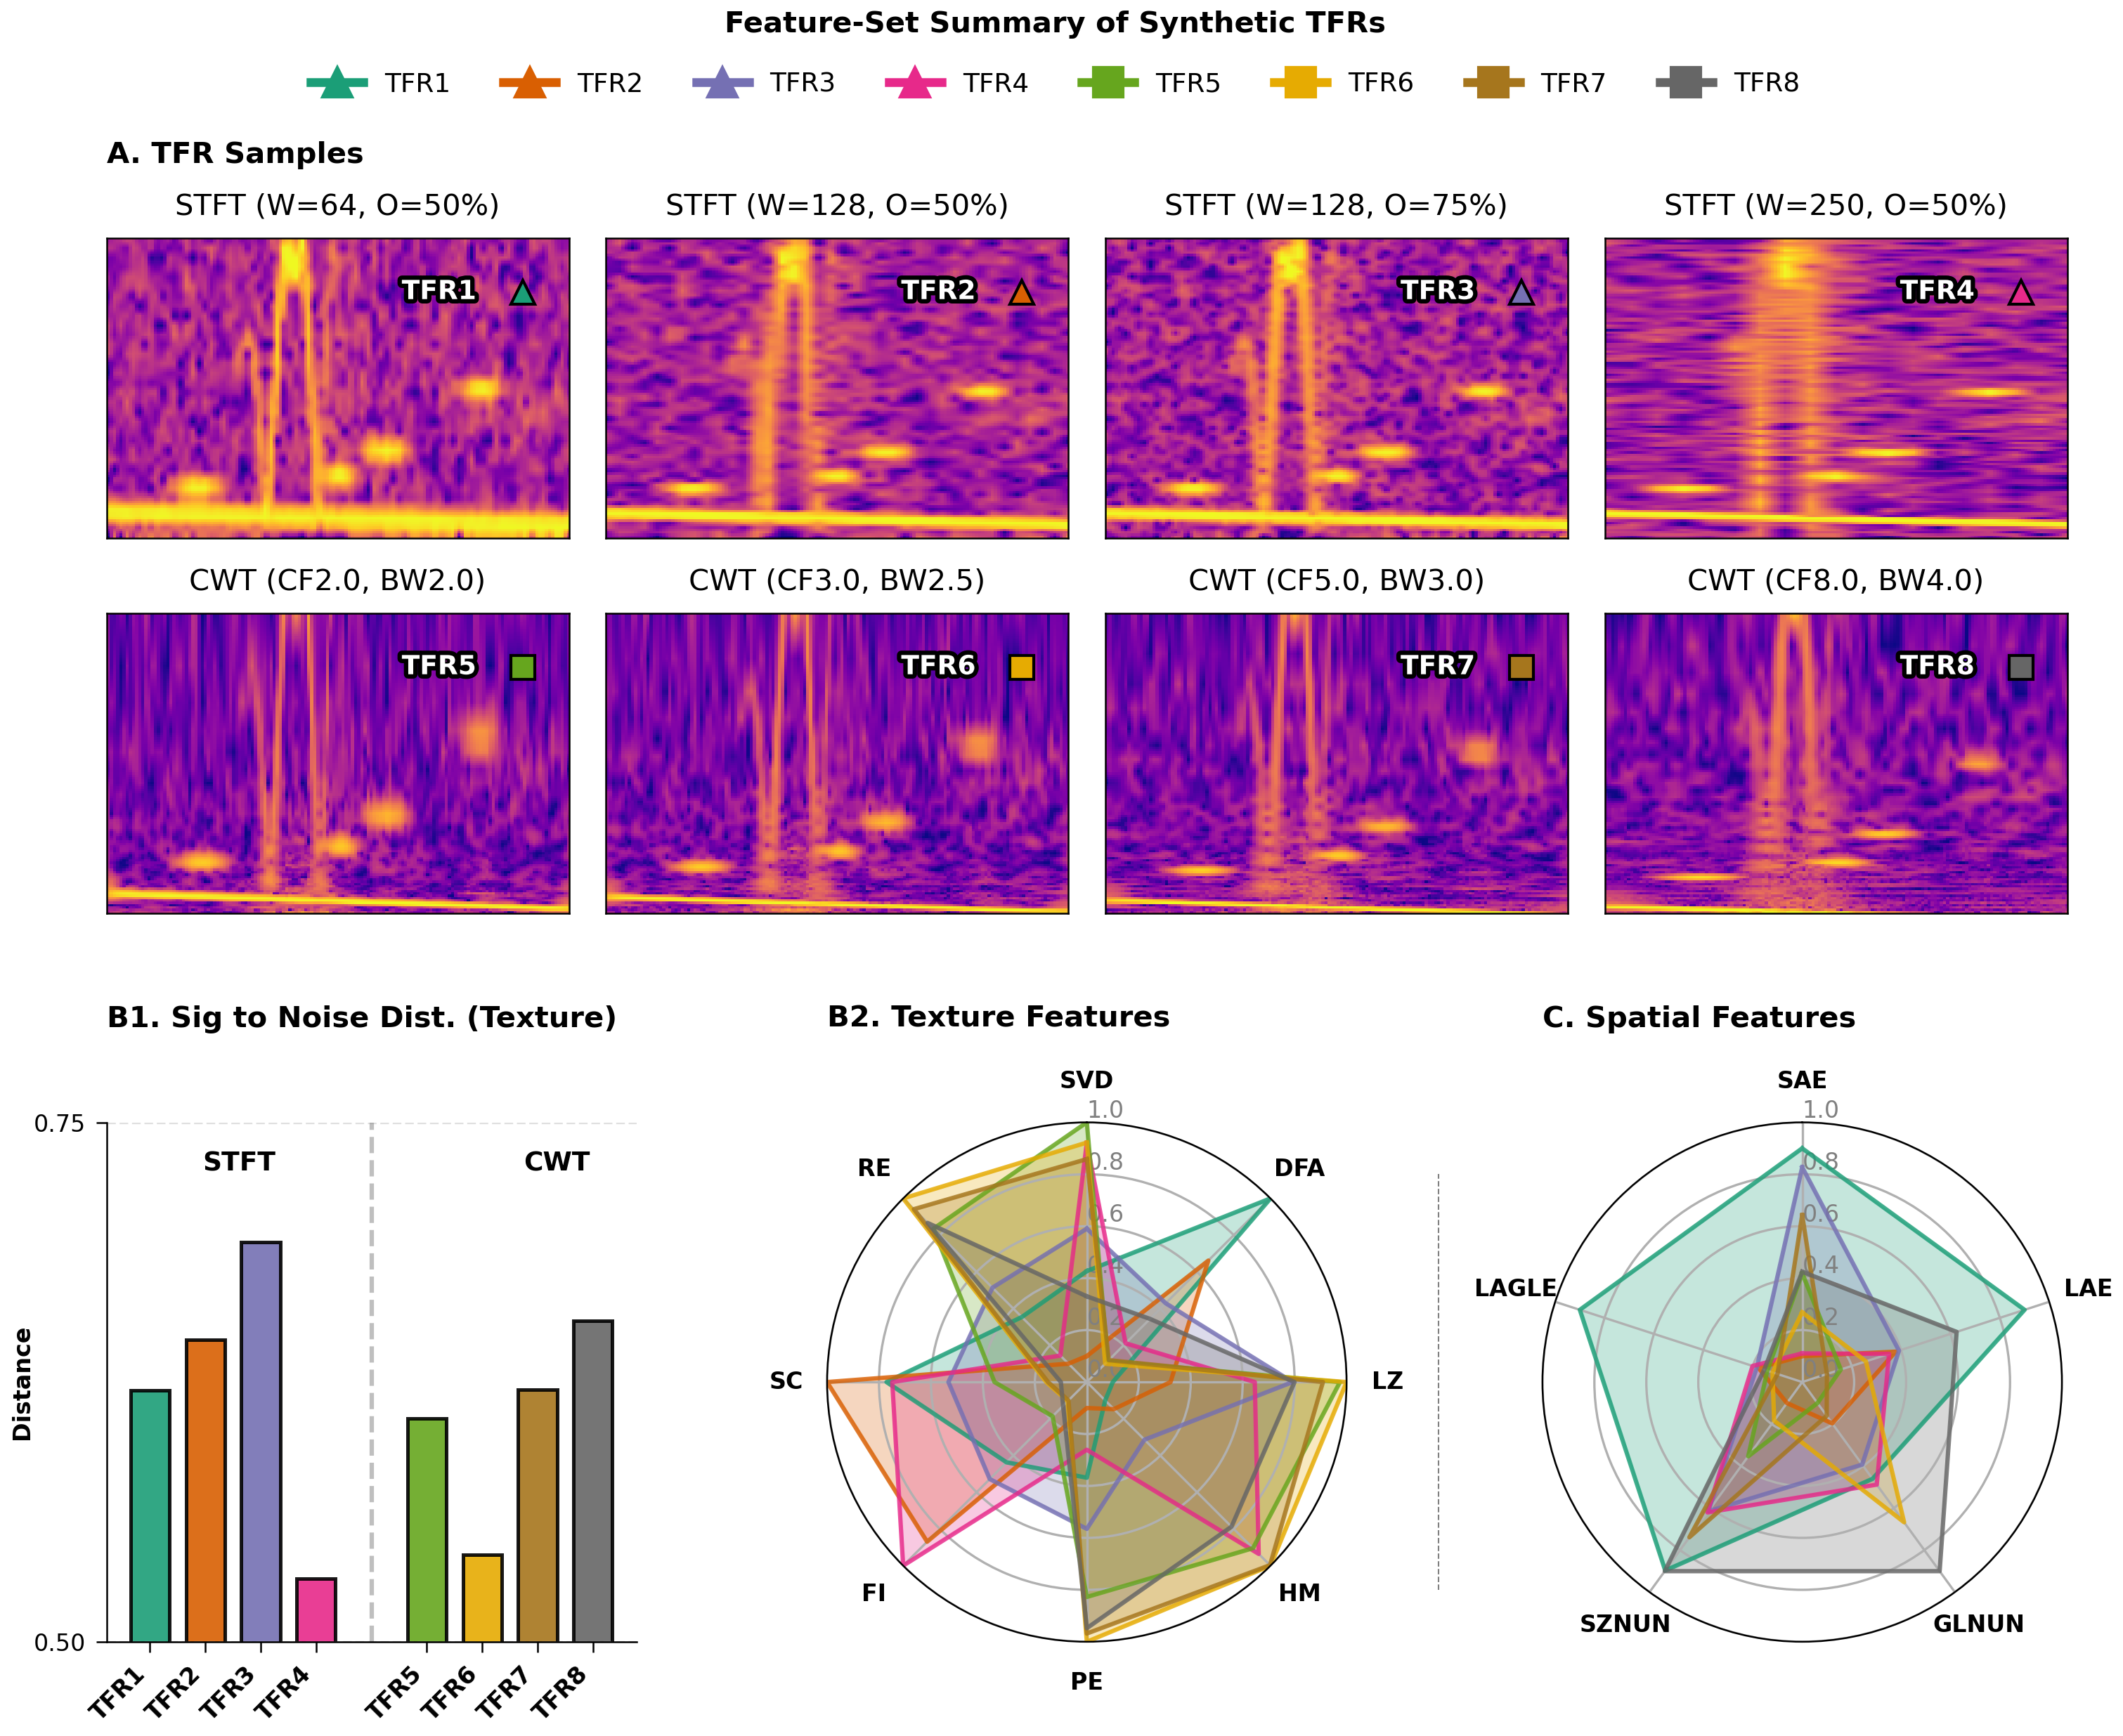

In [ ]:
# ==========================================
# 1. Set Publication RC Params
# ==========================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 9,
    'axes.labelsize': 8,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 9,
    'figure.titlesize': 15, # Added this to let you control the main suptitle
    'lines.linewidth': 1.0,
    'axes.linewidth': 0.6,
    'xtick.major.width': 0.6,
    'ytick.major.width': 0.6,
    'xtick.minor.width': 0.4,
    'ytick.minor.width': 0.4,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05
})

# ==========================================
# 2. Extract and Prepare Data
# ==========================================
descriptive_names = [
    'STFT (W=64, O=50%)', 'STFT (W=128, O=50%)', 
    'STFT (W=128, O=75%)', 'STFT (W=250, O=50%)',
    'CWT (CF2.0, BW2.0)', 'CWT (CF3.0, BW2.5)', 
    'CWT (CF5.0, BW3.0)', 'CWT (CF8.0, BW4.0)'
]
tfr_labels = ['TFR1','TFR2','TFR3','TFR4','TFR5','TFR6','TFR7','TFR8']

cmap = plt.cm.get_cmap('Dark2')
colors = [cmap(i) for i in range(8)]

# ==========================================
# 3. Create Figure & Layout
# ==========================================
fig = plt.figure(figsize=(12, 9))

# Fontsize removed - it will now use 'figure.titlesize' from rcParams
fig.suptitle("Feature-Set Summary of Synthetic TFRs", fontweight='bold', y=0.94, fontsize=10)

legend_handles = []
for i in range(8):
    marker = '^' if i < 4 else 's'
    legend_handles.append(mlines.Line2D([], [], color=colors[i], marker=marker, markersize=10, label=f'TFR{i+1}', linewidth=3))

# Fontsize removed - it will now use 'legend.fontsize' from rcParams
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.92), ncol=8, frameon=False)

gs_main = gridspec.GridSpec(2, 3, height_ratios=[1.3, 1], top=0.82, bottom=0.08, wspace=0.35, hspace=0.35)

# --- PANEL A: TFR Samples ---
gs_A = gridspec.GridSpecFromSubplotSpec(2, 4, subplot_spec=gs_main[0, :], wspace=0.08, hspace=0.25)

for i in range(8):
    ax = fig.add_subplot(gs_A[i // 4, i % 4])
    ax.imshow(all_imgs_orig[i], cmap='plasma', aspect='auto', origin='lower')
    ax.set_title(descriptive_names[i], pad=8)
    ax.set_xticks([]); ax.set_yticks([])
    
    marker = '^' if i < 4 else 's'
    
    # Fontsize removed - defaults to 'font.size'
    txt = ax.text(0.80, 0.82, f'TFR{i+1}', transform=ax.transAxes, color='white', 
                  ha='right', va='center', fontweight='bold',
                  path_effects=[patheffects.withStroke(linewidth=3, foreground='black')])
            
    ax.plot(0.90, 0.82, marker=marker, color=colors[i], markeredgecolor='black', markeredgewidth=1.0,
            transform=ax.transAxes, markersize=8, clip_on=False)
    
    if i == 0:
        # Dynamically bound size to 'axes.titlesize' so it updates perfectly with your other rcParam titles!
        ax.text(0.0, 1.25, 'A. TFR Samples', transform=ax.transAxes,
                size=plt.rcParams['axes.titlesize'], weight='bold', ha='left')


# --- PANEL B (Left Grid): Distance Norm Bar Chart ---
ax_B = fig.add_subplot(gs_main[1, 0])

x_pos = [0, 1, 2, 3, 5, 6, 7, 8] 
for i, key in enumerate(tfr_labels):
    marker = '^' if i < 4 else 's'
    ax_B.bar(x_pos[i], list(entp_l2.values())[i], color=colors[i], edgecolor='black', linewidth=1.2, width=0.7, alpha=0.9)
    ax_B.plot(x_pos[i], 0.05, marker=marker, color='white', markeredgecolor='black', markeredgewidth=1.2, markersize=8)

ax_B.set_xticks(x_pos)
ax_B.set_xticklabels(tfr_labels, rotation=45, fontweight='bold', ha='right')
ax_B.set_title('B1. Sig to Noise Dist. (Texture)', 
               fontweight='bold', loc='left', y=1.15)
ax_B.set_ylabel('Distance', fontweight='bold', labelpad=0)
ax_B.grid(axis='y', linestyle='--', alpha=0.4)
ax_B.spines['top'].set_visible(False)
ax_B.spines['right'].set_visible(False)
ax_B.axvline(x=4, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)

# Fontsize removed - defaults to 'font.size'
ax_B.text(0.25, 0.92, 'STFT', transform=ax_B.transAxes, ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
ax_B.text(0.85, 0.92, 'CWT', transform=ax_B.transAxes, ha='center', va='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
ax_B.set_ylim(0.5, 0.75)
ax_B.set_yticks([0.5, 0.75])

# --- PANEL C (Middle Grid): Texture Metrics Distance Radar ---
ax_C = fig.add_subplot(gs_main[1, 1], polar=True)
c1_cols = ['SVD','DFA','LZ','HM','PE','FI','SC','RE']

_ = gisqa_plots.plot_multi_row_radar_chart(
    df = upd_spec_entp_df_scaled, column_lables = c1_cols, 
    title='', cmap='Dark2', ax=ax_C
)
ax_C.set_title('B2. Texture Features', 
               fontweight='bold', loc='left', y=1.15)

# --- PANEL D (Right Grid): Spatial Metrics Radar ---
ax_D = fig.add_subplot(gs_main[1, 2], polar=True)
e_cols = ['SAE','LAE','GLNUN','SZNUN','LAGLE']
_ = gisqa_plots.plot_multi_row_radar_chart(
    df = glzm_pairwise_metrics_df_stg1_scaled.iloc[:,:-1], column_lables = e_cols, 
    title='', ax=ax_D, cmap='Dark2')
ax_D.set_title('C. Spatial Features', 
               fontweight='bold', loc='left', y=1.15)

divider = Line2D([-0.2, -0.2], [0.1, 0.9], 
                 transform=ax_D.transAxes, 
                 color='gray', 
                 linestyle='--', 
                 linewidth=0.5)

fig.add_artist(divider)

# ==========================================
# 4. Cleanup Subplot Legends
# ==========================================
for ax in [ax_C, ax_D]:
    legend = ax.get_legend()
    if legend: legend.remove()

# ==========================================
# 5. Save and Show
# ==========================================
plt_savename = 'simple_synth2_summary.png'
save_fig_path = 'other_data/all_figures'
os.makedirs(save_fig_path, exist_ok=True)
plt.savefig(os.path.join(save_fig_path, plt_savename))
plt.show()
